In [2]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
import pathlib
import os
import pandas as pd

In [3]:
train_dir = 'Dataset/train'
test_dir = 'Dataset/test'

In [5]:
categories = os.listdir(train_dir)
# Number of images for each disease
nums = {}
for lebal in categories:
    nums[lebal] = len(os.listdir(train_dir + '/' + lebal))

# converting the nums dictionary to pandas dataframe passing index as plant name and number of images as column

img_per_class = pd.DataFrame(nums.values(), index=nums.keys(), columns=["no. of images"])
img_per_class

,no. of images
colon_aca,5000
colon_n,5000


In [6]:
img_height, img_width = 128,128
batch_size = 64

# Load the training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='binary'  # binary classification for cats and dogs
)

# Load the validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='binary'  # binary classification for cats and dogs
)

Found 10000 files belonging to 2 classes.
Using 8000 files for training.
Found 10000 files belonging to 2 classes.
Using 2000 files for validation.


In [18]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam

class SpatialAttention(layers.Layer):
    def __init__(self):
        super(SpatialAttention, self).__init__()
        # Define the Conv2D layer in the initializer to avoid recreating it
        self.conv = layers.Conv2D(1, kernel_size=7, strides=1, padding='same', activation='sigmoid')

    def call(self, inputs):
        avg_pool = tf.reduce_mean(inputs, axis=-1, keepdims=True)  # Average pooling
        max_pool = tf.reduce_max(inputs, axis=-1, keepdims=True)  # Max pooling
        concat = tf.concat([avg_pool, max_pool], axis=-1)  # Concatenate
        attention = self.conv(concat)  # Apply the Conv2D layer
        return inputs * attention  # Element-wise multiplication

# Base ResNet50 model
base_model = tf.keras.applications.ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(img_height, img_width, 3)
)

# Freeze the base model
base_model.trainable = False

# Add spatial attention block
x = base_model.output
x = SpatialAttention()(x)
x = layers.GlobalAveragePooling2D()(x)  # Global average pooling
x = layers.Dropout(0.4)(x)
x = layers.Dense(384, activation='relu')(x)
x = layers.Dropout(0.6)(x)
output = layers.Dense(2, activation='softmax')(x)

# Define the final model
m = Model(inputs=base_model.input, outputs=output)

# Compile the model
m.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_with_spatial_attention.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 128, 128, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 134, 134, 3)       │               0 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 64, 64, 64)        │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 64, 64, 64)        │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 64, 64, 64)        │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 66, 66, 64)        │               0 │ conv1_relu[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 32, 32, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 32, 32, 64)        │           4,160 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 32, 32, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 32, 32, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 32, 32, 64)        │          36,928 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 32, 32, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 32, 32, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_conv (Conv2D)  │ (None, 32, 32, 256)       │          16,640 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_3_conv (Conv2D)  │ (None, 32, 32, 256)       │          16,640 │ conv2_block1_2_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 25,950,472 (98.99 MB)

 Trainable params: 787,586 (3.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

 Optimizer params: 1,575,174 (6.01 MB)

In [19]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint_cb = ModelCheckpoint(
    filepath='best_model_with_spatial_attention.keras',  # Save as a Keras model
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,
    mode='max',
    verbose=1
)

# Train the model with checkpoints
history = m.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[checkpoint_cb]
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7303 - loss: 0.4338
Epoch 1: val_accuracy improved from -inf to 0.98450, saving model to best_model_with_spatial_attention.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 191s 1s/step - accuracy: 0.7314 - loss: 0.4322 - val_accuracy: 0.9845 - val_loss: 0.0495
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9737 - loss: 0.0703
Epoch 2: val_accuracy improved from 0.98450 to 0.99000, saving model to best_model_with_spatial_attention.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 162s 1s/step - accuracy: 0.9737 - loss: 0.0702 - val_accuracy: 0.9900 - val_loss: 0.0315
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9818 - loss: 0.0485
Epoch 3: val_accuracy did not improve from 0.99000
125/125 ━━━━━━━━━━━━━━━━━━━━ 162s 1s/step - accuracy: 0.9817 - loss: 0.0486 - val_accuracy: 0.9880 - val_loss: 0.0354
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 995ms/step - accuracy: 0.9835 - loss: 0.0450
Epoch 4: val_accuracy improved 

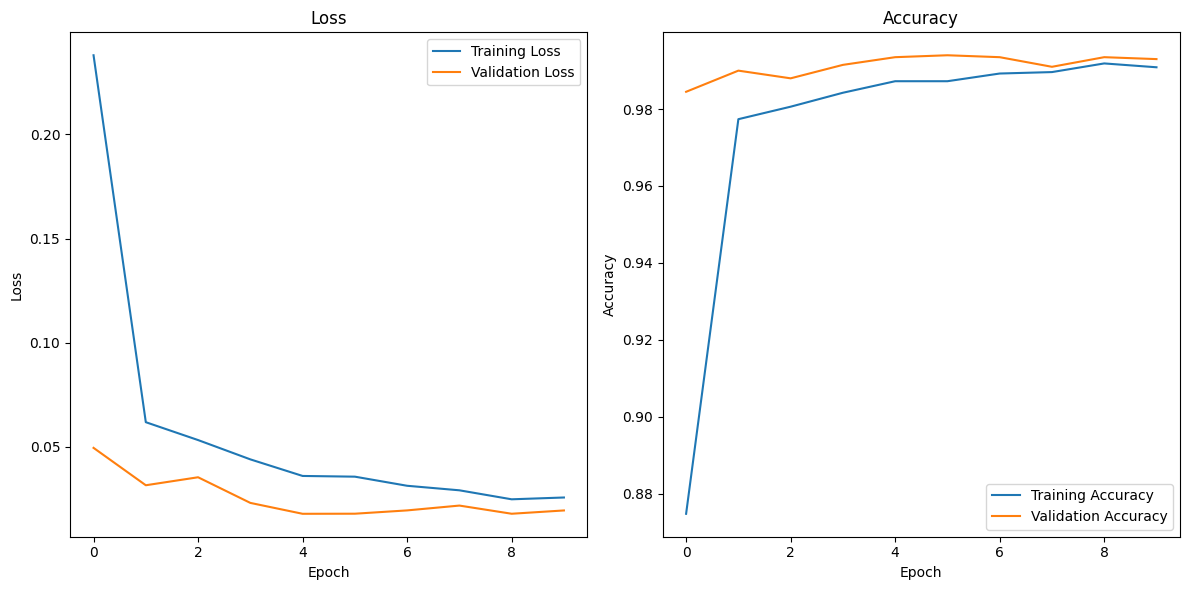

In [20]:
def plot_loss_and_accuracy(history):
    # Plot loss
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_loss_and_accuracy(history)

In [23]:
m.evaluate(train_ds)

125/125 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.9979 - loss: 0.0085


[0.008685010485351086, 0.9982500076293945]

In [24]:
m.evaluate(val_ds)

32/32 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.9960 - loss: 0.0140


[0.019417164847254753, 0.9929999709129333]

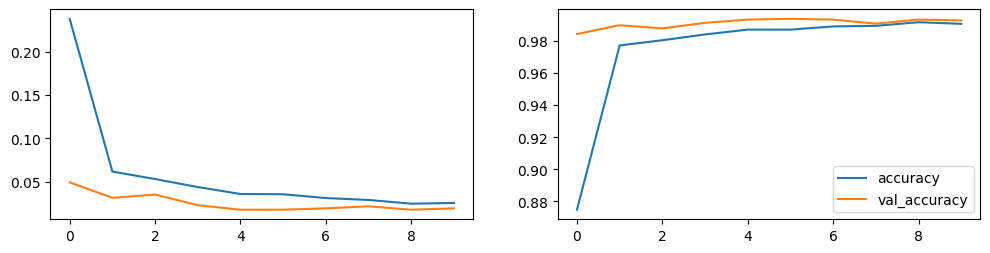

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize = (12, 6))
metrics = ['loss', 'accuracy']
for i in range(2):
    plt.subplot(2, 2, (i + 1))
    plt.plot(history.history[metrics[i]], label = metrics[i])
    plt.plot(history.history['val_{}'.format(metrics[i])], label = 'val_{}'.format(metrics[i]))
plt.legend()

In [28]:
 def get_config(self):
        # Return the configuration of the layer
        return super(SpatialAttention, self).get_config()

In [29]:
m.save('RESNETSA.keras')

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


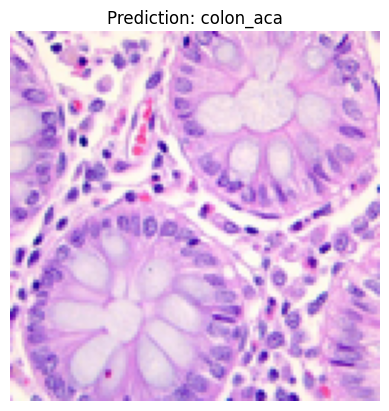

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


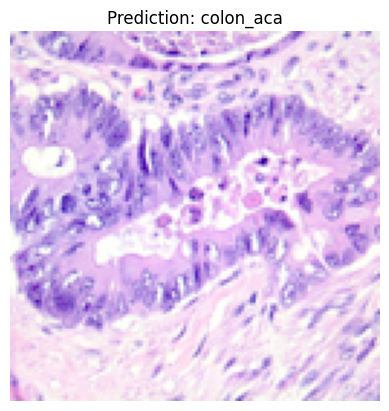

In [32]:
from PIL import Image

def preprocess_image(image_path):
    # Load the image
    image = Image.open(image_path)
    # Resize and normalize the image
    image = image.resize((128, 128))  # Adjust size if needed
    image_array = np.array(image) / 255.0  # Normalize to [0, 1]
    return image_array

def classify_and_display(image_path):
    # Load and preprocess the image
    processed_image = preprocess_image(image_path)
    processed_image = processed_image[None, ...]  # Add batch dimension

    # Get model prediction
    prediction = m.predict(processed_image)
    
    # Get the predicted class
    predicted_class = np.argmax(prediction)
    
    # Prepare labels
    class_labels = {1: 'colon_n', 0: 'colon_aca'}
    predicted_label = class_labels[predicted_class]
    
    # Display the image with prediction
    plt.imshow(processed_image[0])  # Display the original image
    plt.title(f'Prediction: {predicted_label}')
    plt.axis('off')
    plt.show()

# Example usage
image_path = 'Dataset/train/colon_aca/colonca1000.jpeg'  # Replace with your image path
classify_and_display(image_path)

In [ ]:
load 